In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import seaborn as sns

# Load clustering data
clustering_data = pd.read_csv('../Data/SDSS-Gaia_5950stars.csv')
print(f'Data shape: {clustering_data.shape}')
print(f'Columns: {clustering_data.columns.tolist()}')
print(f'\nFirst few rows:')
print(clustering_data.head())

# Display data info
print(f'\nData info:')
print(clustering_data.info())
print(f'\nDescriptive statistics:')
print(clustering_data.describe())

Data shape: (5950, 21)
Columns: ['Unnamed: 0', 'J', 'H', 'K', 'C_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'CA_FE', 'S_FE', 'V_FE', 'CR_FE', 'FE_H', 'CO_FE', 'NI_FE', 'E', 'Energy', 'Lz']

First few rows:
   Unnamed: 0       J       H       K     C_FE      N_FE      O_FE     NA_FE  \
0           0  13.761  12.882  12.733 -0.55730  0.121530 -0.058410 -0.656198   
1           1  14.134  13.344  13.250 -0.55490  0.216510  0.120292 -0.077998   
2           2  14.646  14.024  13.744 -0.57650  0.440610  0.059940  0.247772   
3           3  14.208  13.426  13.346 -0.57267 -0.054657 -0.001759  0.133502   
4           4  13.819  13.031  12.882 -0.59562  0.120780  0.045731 -0.006498   

      MG_FE     AL_FE  ...     CA_FE      S_FE      V_FE     CR_FE     FE_H  \
0 -0.098967 -0.762219  ...  0.031485  0.542042 -0.649838 -0.531586 -1.14850   
1 -0.030772 -0.465619  ...  0.102875  0.176822 -0.500538 -0.282986 -1.05660   
2 -0.013754 -0.213769  ...  0.036315  0.579082  0.339922  0.51

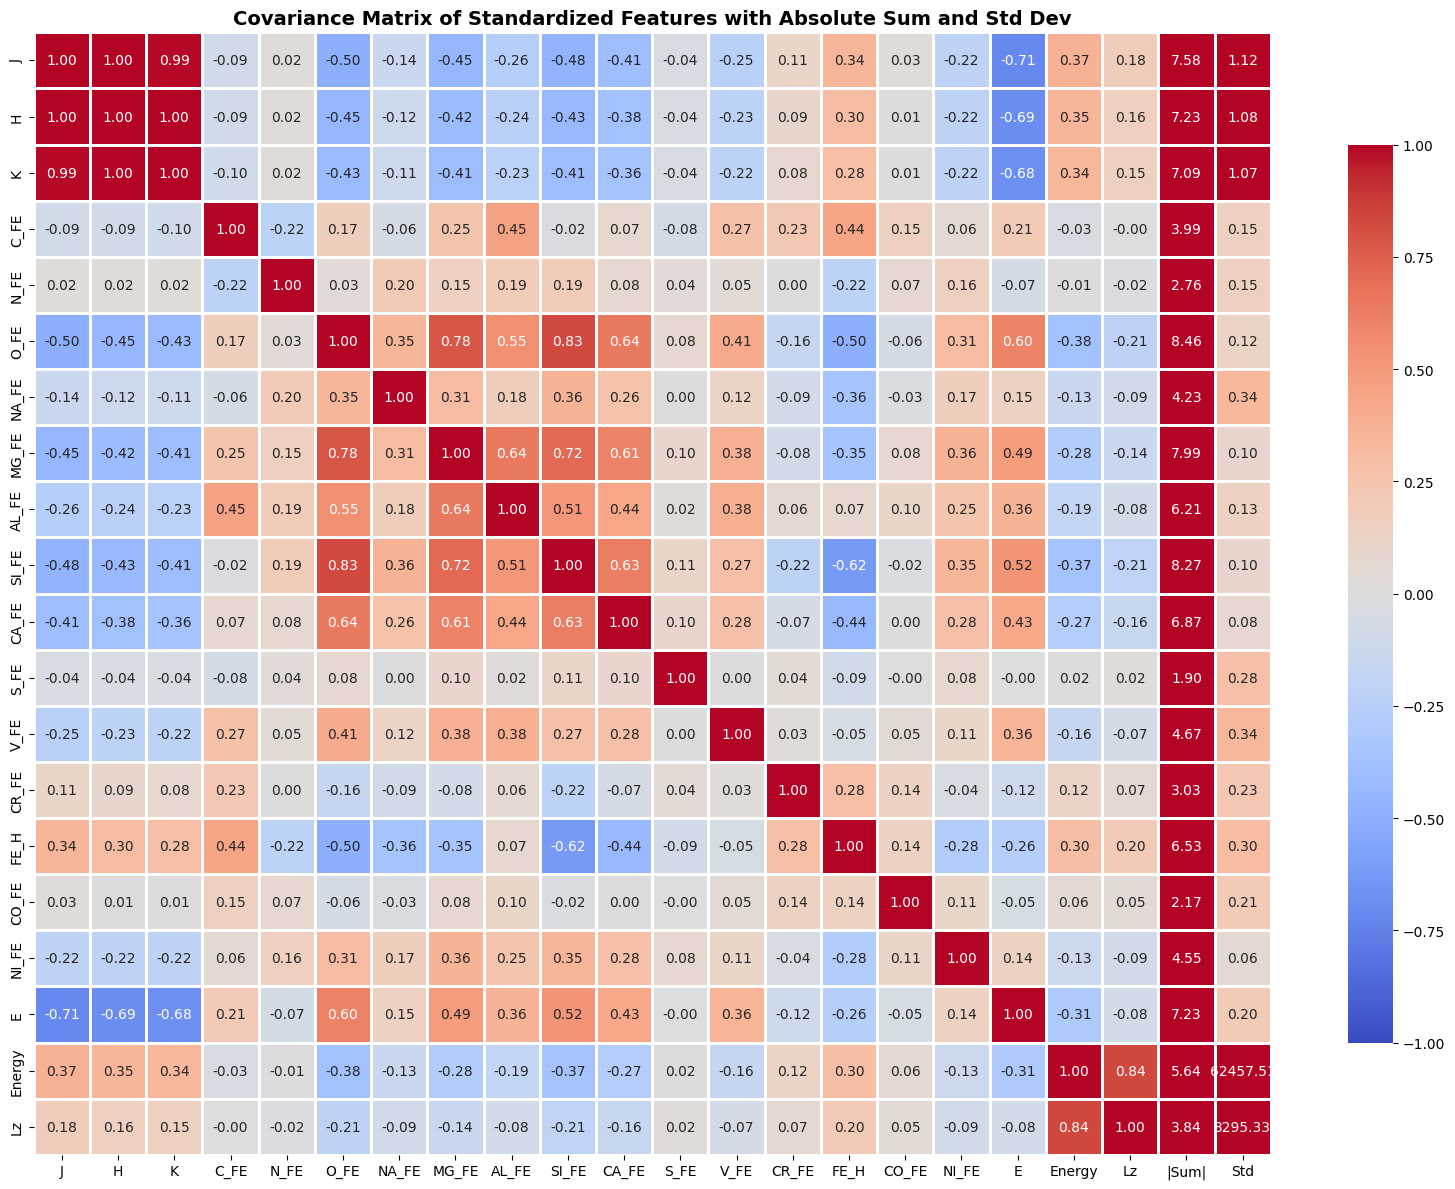

Covariance Matrix shape: (20, 20)
Feature names: ['J', 'H', 'K', 'C_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'CA_FE', 'S_FE', 'V_FE', 'CR_FE', 'FE_H', 'CO_FE', 'NI_FE', 'E', 'Energy', 'Lz']

Feature Statistics (|Sum| of Covariances and Std Dev):
           |Sum|           Std
J       7.580894      1.118370
H       7.228898      1.079531
K       7.089500      1.074965
C_FE    3.986954      0.150228
N_FE    2.755991      0.154497
O_FE    8.458187      0.117848
NA_FE   4.230930      0.335777
MG_FE   7.994732      0.096379
AL_FE   6.208712      0.134582
SI_FE   8.271188      0.095937
CA_FE   6.873275      0.080585
S_FE    1.896523      0.278054
V_FE    4.673176      0.335958
CR_FE   3.029614      0.230567
FE_H    6.529840      0.302236
CO_FE   2.170835      0.207264
NI_FE   4.550868      0.061567
E       7.226794      0.198746
Energy  5.636959  62457.506059
Lz      3.838796   3295.330251


In [22]:
# Calculate and plot covariance matrix
# Select only numeric columns and remove NaN values
numeric_data = clustering_data.select_dtypes(include=[np.number]).dropna()
# Exclude the first column (index)
numeric_data = numeric_data.iloc[:, 1:]

# Standardize the data to handle different scales
scaler = StandardScaler()
standardized_data = scaler.fit_transform(numeric_data)
standardized_df = pd.DataFrame(standardized_data, columns=numeric_data.columns)

# Compute covariance on standardized data (this is equivalent to correlation matrix)
cov_matrix = standardized_df.cov()

# Calculate absolute sum of covariances for each feature
abs_sum_cov = cov_matrix.abs().sum(axis=1)

# Calculate standard deviation of each feature
feature_std = numeric_data.std()

# Create a new column for the sum and standard deviation, add them to the matrix
cov_matrix_with_sum = cov_matrix.copy()
cov_matrix_with_sum['|Sum|'] = abs_sum_cov
cov_matrix_with_sum['Std'] = feature_std

# Create heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(cov_matrix_with_sum, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=False, linewidths=1, cbar_kws={"shrink": 0.8}, 
            vmin=-1, vmax=1)
plt.title('Covariance Matrix of Standardized Features with Absolute Sum and Std Dev', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Covariance Matrix shape: {cov_matrix.shape}')
print(f'Feature names: {numeric_data.columns.tolist()}')
print(f'\nFeature Statistics (|Sum| of Covariances and Std Dev):\n{cov_matrix_with_sum[["|Sum|", "Std"]].to_string()}')

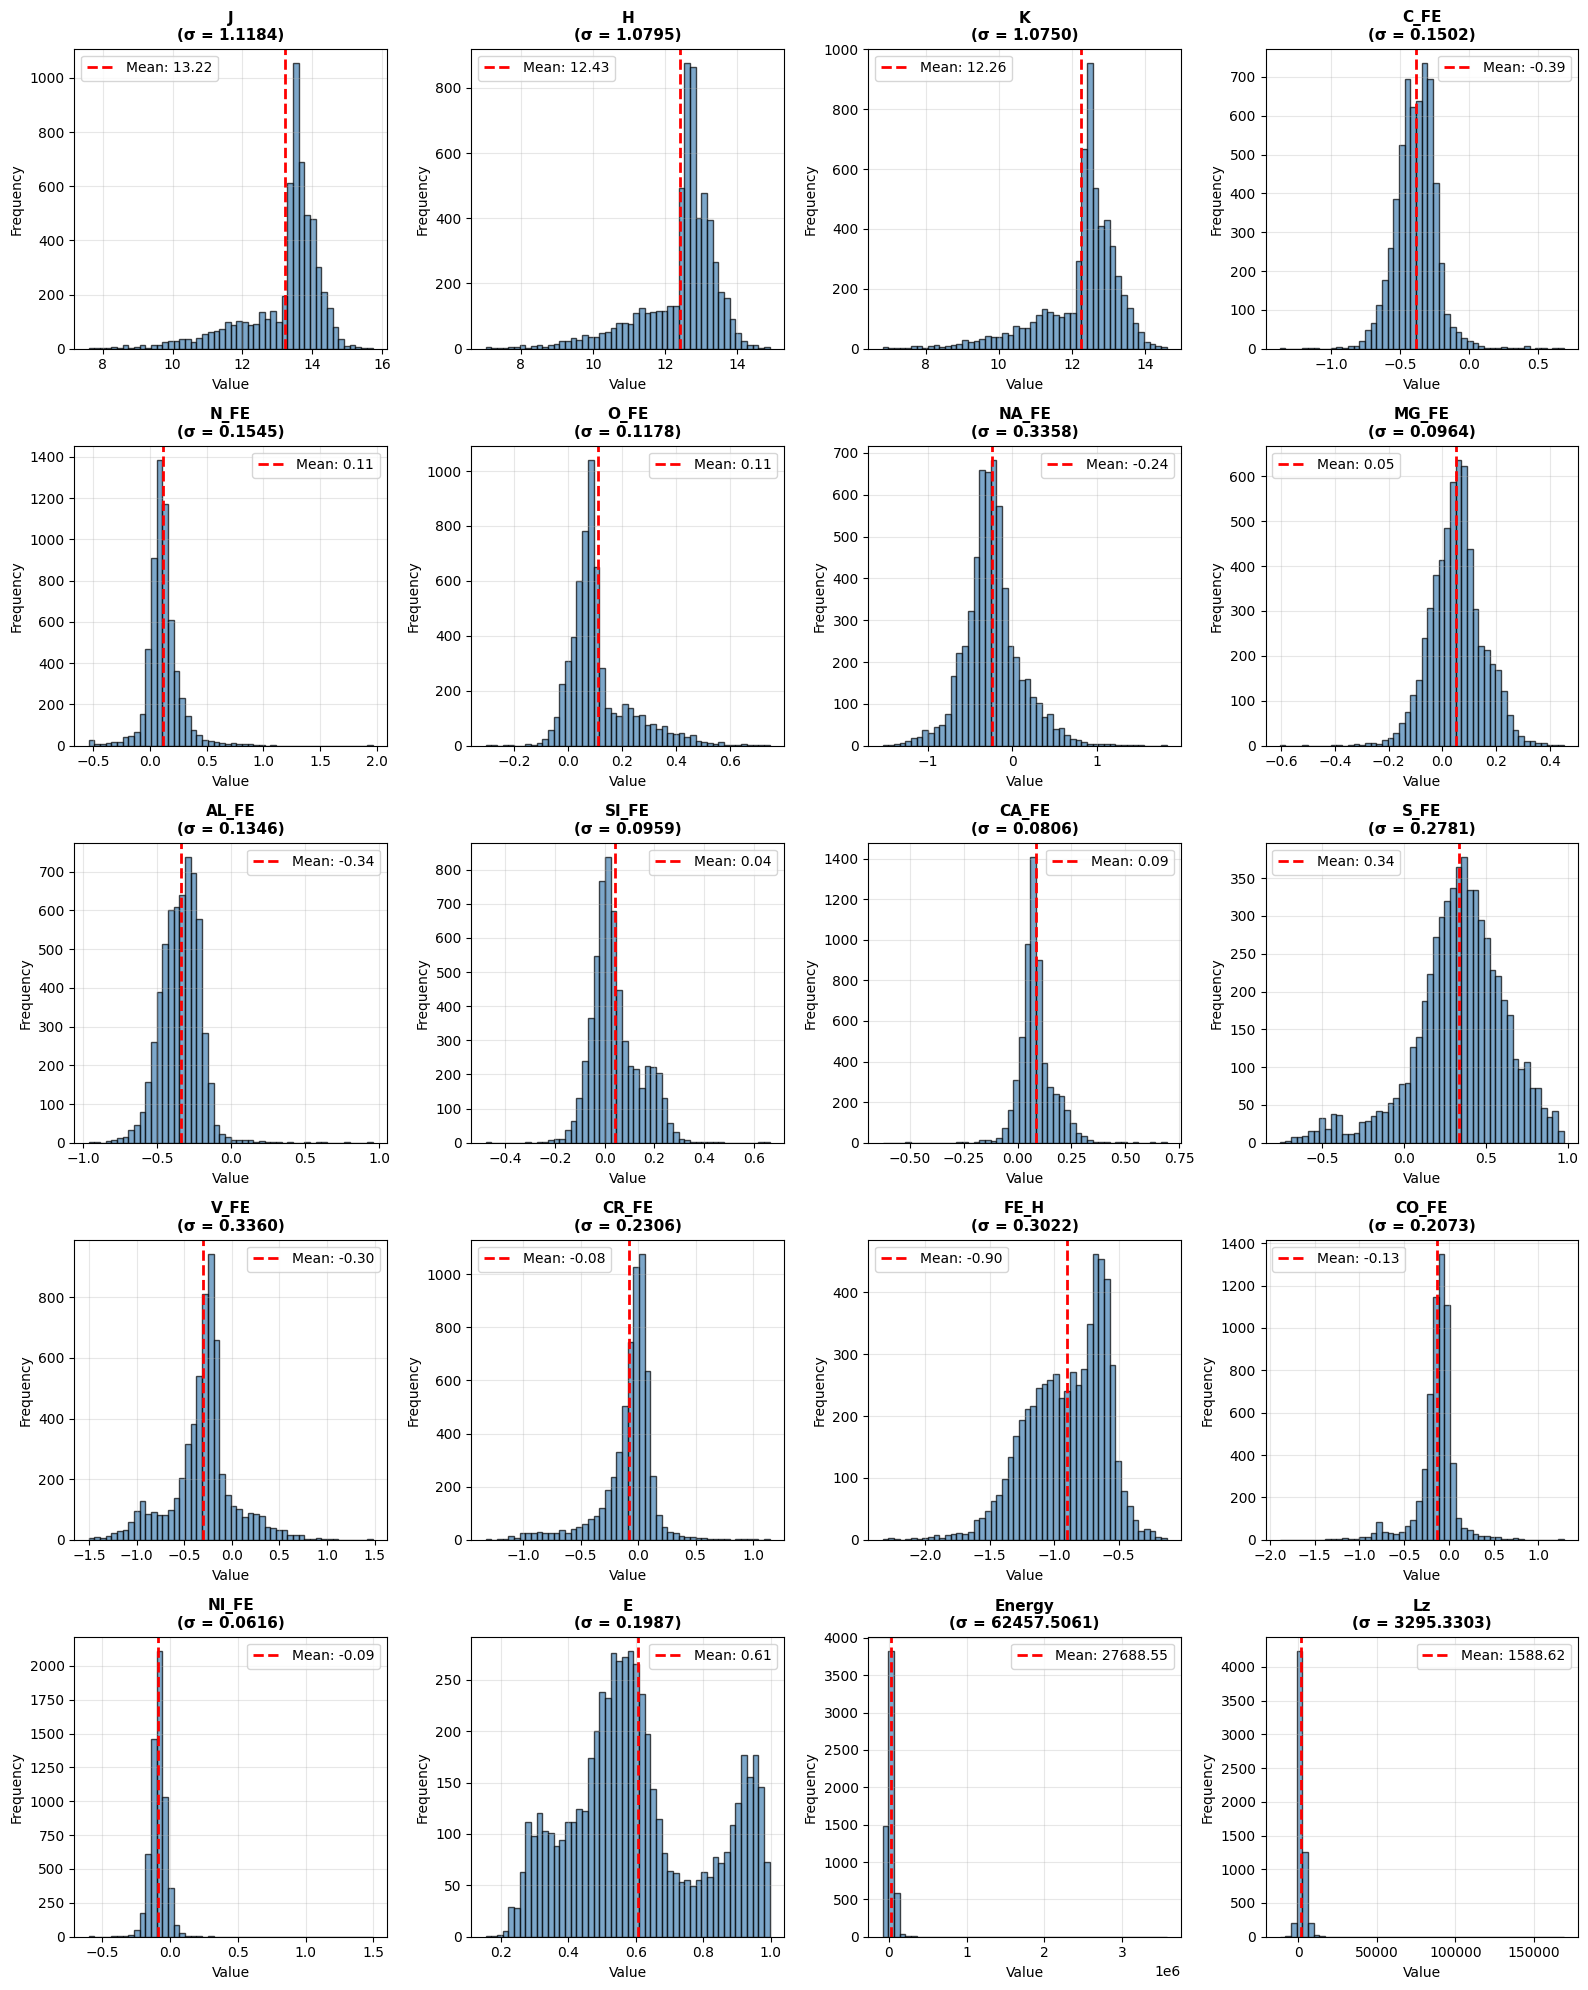

Distribution plots created for 20 features


In [13]:
# Plot distribution of each variable with standard deviation
# Skip the first column (index) - already done in covariance cell
n_features = numeric_data.shape[1]
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_data.columns):
    ax = axes[idx]
    std_dev = numeric_data[col].std()
    mean_val = numeric_data[col].mean()
    
    # Plot histogram
    ax.hist(numeric_data[col], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    
    # Add vertical line for mean
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    
    ax.set_title(f'{col}\n(σ = {std_dev:.4f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

# Remove empty subplots
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print(f'Distribution plots created for {n_features} features')

Selected features used for clustering: ['J', 'E', 'C_FE', 'O_FE', 'FE_H', 'S_FE']
Best k by silhouette: 2 (silhouette=0.4194)
KMeans (k=2) — Silhouette: 0.4194, Davies-Bouldin: 1.1138
KMeans cluster sizes: {np.int32(0): np.int64(4521), np.int32(1): np.int64(1429)}
DBSCAN found 24 clusters (including noise).
DBSCAN silhouette (ignoring noise): -0.1306

Head of clustered data (selected features + labels):
        J         E     C_FE      O_FE     FE_H      S_FE  kmeans_cluster  \
0  13.761  0.306008 -0.55730 -0.058410 -1.14850  0.542042             0.0   
1  14.134  0.391866 -0.55490  0.120292 -1.05660  0.176822             0.0   
2  14.646  0.629223 -0.57650  0.059940 -0.98495  0.579082             0.0   
3  14.208  0.333420 -0.57267 -0.001759 -1.16200  0.142352             0.0   
4  13.819  0.347582 -0.59562  0.045731 -1.33410  0.678072             0.0   

   dbscan_cluster  
0             0.0  
1             0.0  
2            -1.0  
3            -1.0  
4             0.0  


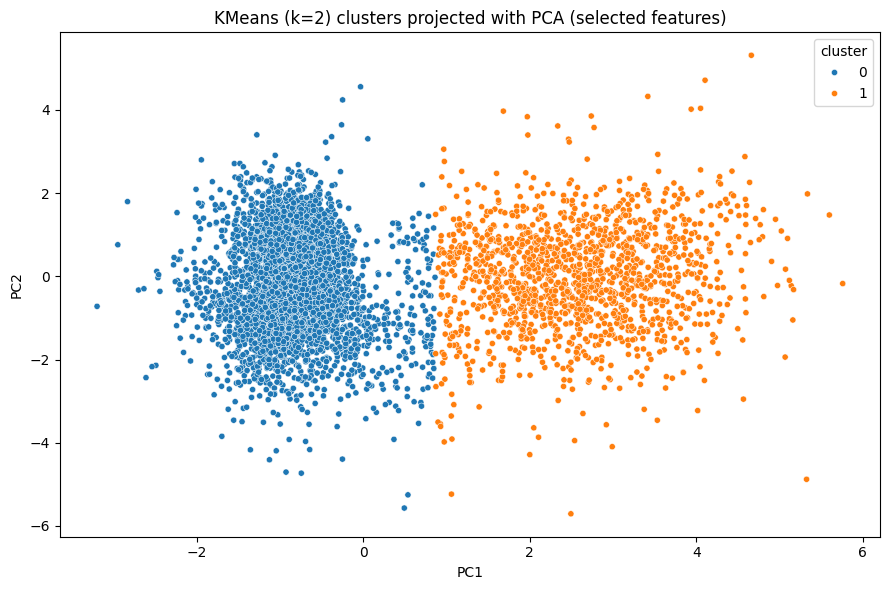


Clustering on selected features complete.


In [29]:
# Train clustering models on the user-selected features
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# User-selected features
selected_features = ['J', 'E', 'C_FE', 'O_FE', 'FE_H', 'S_FE']
print('Selected features used for clustering:', selected_features)

# Prepare data: drop rows with NaNs in selected features
X_df = numeric_data[selected_features].dropna()

# Standardize selected features
scaler_sel = StandardScaler()
X_scaled = scaler_sel.fit_transform(X_df)

# Find best K using silhouette score
sil_scores = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

best_k = K_range[int(np.argmax(sil_scores))]
print(f'Best k by silhouette: {best_k} (silhouette={max(sil_scores):.4f})')

# Fit final KMeans on selected features
kmeans_sel = KMeans(n_clusters=best_k, random_state=42, n_init=10)
k_labels = kmeans_sel.fit_predict(X_scaled)

# Evaluate
sil_k = silhouette_score(X_scaled, k_labels)
db_k = davies_bouldin_score(X_scaled, k_labels)
print(f'KMeans (k={best_k}) — Silhouette: {sil_k:.4f}, Davies-Bouldin: {db_k:.4f}')

# Cluster sizes
unique, counts = np.unique(k_labels, return_counts=True)
print('KMeans cluster sizes:', dict(zip(unique, counts)))

# Try DBSCAN on selected features (tune eps if needed)
dbscan = DBSCAN(eps=0.5, min_samples=5)
d_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(d_labels)) - (1 if -1 in d_labels else 0)
print(f'DBSCAN found {n_clusters_db} clusters (including noise).')
if n_clusters_db > 1:
    try:
        sil_db = silhouette_score(X_scaled[d_labels != -1], d_labels[d_labels != -1])
        print(f'DBSCAN silhouette (ignoring noise): {sil_db:.4f}')
    except Exception:
        pass

# Add labels back to a copy of the original numeric_data (align by index)
clustered_df = numeric_data.copy()
# Initialize with NaN then fill only the rows that remained after dropna
clustered_df['kmeans_cluster'] = np.nan
clustered_df['dbscan_cluster'] = np.nan
clustered_df.loc[X_df.index, 'kmeans_cluster'] = k_labels
clustered_df.loc[X_df.index, 'dbscan_cluster'] = d_labels

print('\nHead of clustered data (selected features + labels):')
print(clustered_df[selected_features + ['kmeans_cluster', 'dbscan_cluster']].head())

# PCA projection for visualization (on selected, scaled features)
pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(X_scaled)

plt.figure(figsize=(9,6))
sns.scatterplot(x=proj[:,0], y=proj[:,1], hue=k_labels, palette='tab10', s=20, legend='full')
plt.title(f'KMeans (k={best_k}) clusters projected with PCA (selected features)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='cluster')
plt.tight_layout()
plt.show()

print('\nClustering on selected features complete.')

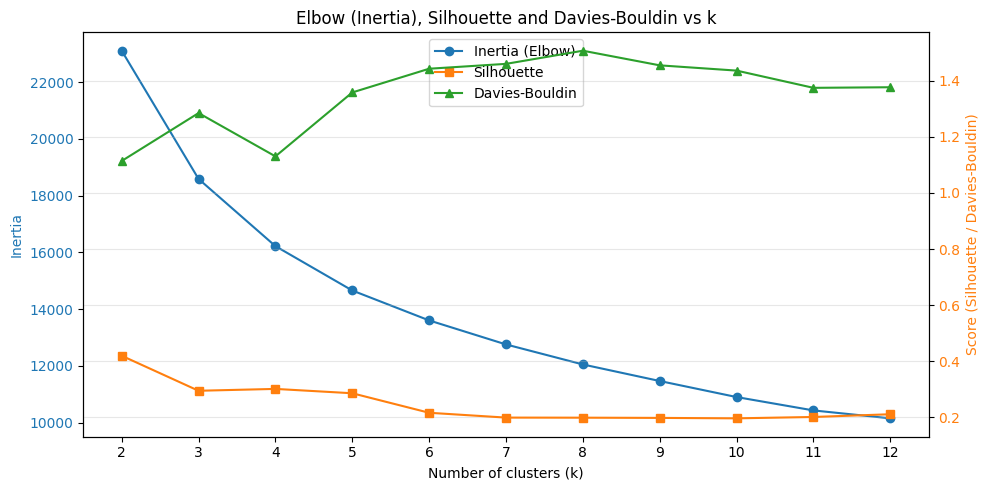

         inertia  silhouette  davies_bouldin
k                                           
2   23111.081103    0.419442        1.113832
3   18589.454241    0.294637        1.284652
4   16220.426020    0.301257        1.130286
5   14656.046289    0.285749        1.358132
6   13600.887748    0.216193        1.442687
7   12753.893303    0.198969        1.460016
8   12048.156871    0.198662        1.506901
9   11464.492841    0.197887        1.454752
10  10898.630718    0.196330        1.436006
11  10427.287620    0.201205        1.374567
12  10147.985695    0.210924        1.376676


In [30]:
# Plot elbow (inertia), silhouette score and Davies-Bouldin score vs. number of clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

K_range = range(2, 13)
inertias = []
sil_scores_k = []
db_scores_k = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores_k.append(silhouette_score(X_scaled, labels_k))
    db_scores_k.append(davies_bouldin_score(X_scaled, labels_k))

# Plot
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(list(K_range), inertias, marker='o', color='tab:blue', label='Inertia (Elbow)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(list(K_range), sil_scores_k, marker='s', color='tab:orange', label='Silhouette')
ax2.plot(list(K_range), db_scores_k, marker='^', color='tab:green', label='Davies-Bouldin')
ax2.set_ylabel('Score (Silhouette / Davies-Bouldin)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center')
plt.title('Elbow (Inertia), Silhouette and Davies-Bouldin vs k')
plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print values for inspection
metrics_df = pd.DataFrame({
    'k': list(K_range),
    'inertia': inertias,
    'silhouette': sil_scores_k,
    'davies_bouldin': db_scores_k
}).set_index('k')
print(metrics_df)
